In [ ]:
# ============================================================
# CELL 1: CLEAR GPU / RAM
# ============================================================
import gc
import torch

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("GPU cleared.")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU cleared.
CUDA available: True
GPU Name: Tesla T4


In [ ]:
# ============================================================
# CELL 2: INSTALL REQUIRED PACKAGES
# ============================================================
!pip install -q -U transformers==4.41.2 accelerate==0.30.1 datasets evaluate
!pip install -q -U sentencepiece sacrebleu rouge_score gdown peft bitsandbytes trl

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
trl 1.0.0 requires accelerate>=1.4.0, but you have accelerate 0.30.1 which is incompatible.
trl 1.0.0 requires transformers>=4.56.2, but you have transformers 4.41.2 which is incompatible.


In [ ]:
# ============================================================
# CELL 3: IMPORTS
# ============================================================
import os
import re
import gc
import math
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.model_selection import train_test_split

from datasets import Dataset
import evaluate
import gdown

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
# ============================================================
# CELL 4: DOWNLOAD DATASET FROM GOOGLE DRIVE (FIXED)
# ============================================================
import os
import gdown
import pandas as pd

# আপনার দেওয়া লিঙ্কের ID: 1RLvYgiQ_Fpd6UyXLWOzIXQuJdaaqIuqI
file_id = "1RLvYgiQ_Fpd6UyXLWOzIXQuJdaaqIuqI"

# সরাসরি ডাউনলোডের জন্য URL ফরম্যাট (Export as CSV)
url = f'https://drive.google.com/uc?id={file_id}'

out_file = "recommendation_dataset.csv"

# যদি আগের ফাইল থাকে তবে তা রিমুভ করা (নতুন ডাটা নিশ্চিত করতে)
if os.path.exists(out_file):
    os.remove(out_file)
    print(f"Old {out_file} removed.")

print("Downloading dataset from Google Drive...")
gdown.download(url, out_file, quiet=False)

# ডাটা লোড করা
# যেহেতু ফাইলটি এক্সেল ফরম্যাটে থাকতে পারে, তাই যদি read_csv তে এরর দেয় তবে read_excel ব্যবহার করতে হতে পারে
try:
    df = pd.read_csv(out_file)
except:
    # যদি CSV হিসেবে না পড়ে, তবে এক্সেল হিসেবে ট্রাই করবে
    df = pd.read_excel(out_file)

print("\n--- Dataset Loaded ---")
print("Original Shape:", df.shape)
print(df.head())

Old recommendation_dataset.csv removed.


Downloading...
From: https://drive.google.com/uc?id=1RLvYgiQ_Fpd6UyXLWOzIXQuJdaaqIuqI
To: /content/recommendation_dataset.csv
100%|██████████| 1.14M/1.14M [00:00<00:00, 158MB/s]


--- Dataset Loaded ---
Original Shape: (718, 6)
     paper_name     publication_date  \
0  thedailystar      29/10/2024 2:33   
1  thedailystar  2024-01-10 14:08:00   
2  thedailystar      16/12/2025 0:41   
3  thedailystar      16/12/2025 0:00   
4  thedailystar      16/12/2025 0:40   

                                            headline  \
0  BB probe into Union Bank: Ã¢â‚¬ËœS Alam staffe...   
1  Workers block highway for 2nd day, 15-km tailb...   
2  Farmers reduce potato acreage for next year af...   
3    Bangladesh spent $26b on debt servicing in FY24   
4        External deficit widens to $749m in Jul-Oct   

                                          clean_text Sentiment_Label  \
0  bb probe into union bank: Ã¢â‚¬Ëœs alam staffe...        Negative   
1  workers block highway for 2nd day, 15-km tailb...        Negative   
2  farmers reduce potato acreage for next year af...        Negative   
3  bangladesh spent $26b on debt servicing in fy2...        Negative   
4  external d

In [ ]:
# ============================================================
# CELL 5: KEEP ONLY REQUIRED COLUMNS
# ============================================================
required_cols = [
    "paper_name",
    "publication_date",
    "headline",
    "clean_text",
    "Sentiment_Label",
    "Recommend_text"
]

df = df[required_cols].copy()
print("After selecting columns:", df.shape)
df.head()

After selecting columns: (718, 6)


,paper_name,publication_date,headline,clean_text,Sentiment_Label,Recommend_text
0,thedailystar,29/10/2024 2:33,BB probe into Union Bank: Ã¢â‚¬ËœS Alam staffe...,bb probe into union bank: Ã¢â‚¬Ëœs alam staffe...,Negative,Strengthen internal banking controls and ensur...
1,thedailystar,2024-01-10 14:08:00,"Workers block highway for 2nd day, 15-km tailb...","workers block highway for 2nd day, 15-km tailb...",Negative,Timely payment of workers' wages and dues is e...
2,thedailystar,16/12/2025 0:41,Farmers reduce potato acreage for next year af...,farmers reduce potato acreage for next year af...,Negative,"To address this issue, the government should i..."
3,thedailystar,16/12/2025 0:00,Bangladesh spent $26b on debt servicing in FY24,bangladesh spent $26b on debt servicing in fy2...,Negative,"To improve the situation, the government shoul..."
4,thedailystar,16/12/2025 0:40,External deficit widens to $749m in Jul-Oct,external deficit widens to $749m in jul-oct. b...,Negative,"To address the widening external deficit, the ..."


In [ ]:
# ============================================================
# CELL 6: CLEAN DATASET
# ============================================================
for col in required_cols:
    df[col] = df[col].fillna("").astype(str)

# Remove empty targets
df = df[df["Recommend_text"].str.strip() != ""].copy()

# Remove duplicates
df = df.drop_duplicates(
    subset=["headline", "clean_text", "Recommend_text"]
).reset_index(drop=True)

print("After cleaning:", df.shape)
df[["headline", "Sentiment_Label", "Recommend_text"]].head(3)

After cleaning: (718, 6)


,headline,Sentiment_Label,Recommend_text
0,BB probe into Union Bank: Ã¢â‚¬ËœS Alam staffe...,Negative,Strengthen internal banking controls and ensur...
1,"Workers block highway for 2nd day, 15-km tailb...",Negative,Timely payment of workers' wages and dues is e...
2,Farmers reduce potato acreage for next year af...,Negative,"To address this issue, the government should i..."


In [ ]:
# ============================================================
# CELL 7: CREATE INPUT AND TARGET TEXT
# ============================================================
def build_input_text(row):
    return f"""Generate a financial recommendation based on the news.

Paper Name: {row['paper_name']}
Publication Date: {row['publication_date']}
Headline: {row['headline']}
News Text: {row['clean_text']}
Sentiment: {row['Sentiment_Label']}

Recommendation:"""

df["input_text"] = df.apply(build_input_text, axis=1)
df["target_text"] = df["Recommend_text"].astype(str)

print(df[["input_text", "target_text"]].head(2).to_string())

In [ ]:
# ============================================================
# CELL 8: TRAIN / VALIDATION / TEST SPLIT
# ============================================================
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED
)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 574
Val  : 72
Test : 72


In [ ]:
# ============================================================
# CELL 9: CONVERT TO HUGGING FACE DATASET
# ============================================================
train_ds = Dataset.from_pandas(train_df[["input_text", "target_text"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[["input_text", "target_text"]].reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df[["input_text", "target_text"]].reset_index(drop=True))

print(train_ds)
print(val_ds)
print(test_ds)

Dataset({
    features: ['input_text', 'target_text'],
    num_rows: 574
})
Dataset({
    features: ['input_text', 'target_text'],
    num_rows: 72
})
Dataset({
    features: ['input_text', 'target_text'],
    num_rows: 72
})


In [ ]:
# ============================================================
# CELL 10: LOAD METRICS
# ============================================================
rouge = evaluate.load("rouge")
bleu = evaluate.load("sacrebleu")

def clean_generated_text(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

def compute_text_generation_metrics(predictions, references):
    predictions = [clean_generated_text(p) for p in predictions]
    references  = [clean_generated_text(r) for r in references]

    rouge_result = rouge.compute(
        predictions=predictions,
        references=references
    )

    bleu_result = bleu.compute(
        predictions=predictions,
        references=[[r] for r in references]
    )

    metrics = {
        "rouge1": round(rouge_result["rouge1"], 4),
        "rouge2": round(rouge_result["rouge2"], 4),
        "rougeL": round(rouge_result["rougeL"], 4),
        "bleu": round(bleu_result["score"], 4)
    }
    return metrics

In [ ]:
# ============================================================
# CELL 11: LOAD FLAN-T5 MODEL
# ============================================================
T5_MODEL_NAME = "google/flan-t5-base"   # use flan-t5-small if GPU is low
MAX_INPUT_LEN = 512
MAX_TARGET_LEN = 128

t5_tokenizer = AutoTokenizer.from_pretrained(T5_MODEL_NAME)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(T5_MODEL_NAME).to(device)

print("Model loaded:", T5_MODEL_NAME)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Model loaded: google/flan-t5-base


In [ ]:
# ============================================================
# CELL 12: TOKENIZATION FUNCTION (FIXED)
# ============================================================
def preprocess_t5(example):
    model_inputs = t5_tokenizer(
        example["input_text"],
        max_length=MAX_INPUT_LEN,
        truncation=True
    )

    labels = t5_tokenizer(
        text_target=example["target_text"],
        max_length=MAX_TARGET_LEN,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [ ]:
# ============================================================
# CELL 13: APPLY TOKENIZATION (FIXED)
# ============================================================
train_t5 = train_ds.map(preprocess_t5)
val_t5   = val_ds.map(preprocess_t5)
test_t5  = test_ds.map(preprocess_t5)

# Remove raw text columns so Trainer only sees tokenized features
train_t5 = train_t5.remove_columns(["input_text", "target_text"])
val_t5   = val_t5.remove_columns(["input_text", "target_text"])
test_t5  = test_t5.remove_columns(["input_text", "target_text"])

print(train_t5[0])
print(val_t5[0])

Map:   0%|          | 0/574 [00:00<?, ? examples/s]

Map:   0%|          | 0/72 [00:00<?, ? examples/s]

Map:   0%|          | 0/72 [00:00<?, ? examples/s]

{'input_ids': [6939, 2206, 3, 9, 981, 10919, 3, 390, 30, 8, 1506, 5, 6564, 5570, 10, 8, 26, 9, 9203, 3624, 2575, 257, 7678, 10, 604, 20223, 20173, 1828, 1003, 10, 1828, 3642, 747, 10, 9794, 17, 18, 9514, 4603, 138, 19330, 521, 4396, 430, 12107, 774, 3529, 5027, 10, 2814, 18, 9514, 3, 776, 138, 4514, 7002, 4396, 430, 12107, 774, 5, 8, 3, 776, 138, 4514, 7002, 2656, 3293, 7, 16, 20, 17789, 152, 354, 95, 9, 702, 521, 13, 7620, 138, 3791, 65, 4258, 26, 999, 18905, 3, 9, 15187, 2814, 13, 3, 17, 157, 431, 4834, 5, 3072, 23095, 6, 72, 145, 985, 13, 84, 19, 23030, 15, 26, 2137, 1046, 5, 8, 3293, 1553, 48, 215, 31, 7, 2656, 1608, 15, 12107, 774, 30, 3, 5326, 18247, 2059, 5, 1315, 12, 3293, 4298, 6, 8, 2387, 21, 48, 774, 19, 12, 22802, 3, 28891, 19637, 13, 2656, 1608, 15, 12, 1759, 3, 5898, 19637, 13, 2656, 5, 2127, 16, 24011, 28, 981, 11, 2268, 2927, 45, 8, 258, 3, 16864, 343, 152, 11, 126, 3, 776, 138, 232, 10524, 6, 8, 3293, 19, 80, 13, 8, 10043, 11, 167, 10331, 2437, 2913, 3173, 16, 7620, 13

In [ ]:
# ============================================================
# CELL 14: DATA COLLATOR + METRICS
# ============================================================
t5_data_collator = DataCollatorForSeq2Seq(
    tokenizer=t5_tokenizer,
    model=t5_model,
    label_pad_token_id=-100
)

def compute_metrics_t5(eval_preds):
    preds, labels = eval_preds

    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = t5_tokenizer.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, t5_tokenizer.pad_token_id)
    decoded_labels = t5_tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [clean_generated_text(p) for p in decoded_preds]
    decoded_labels = [clean_generated_text(l) for l in decoded_labels]

    # Debug print
    print("\nSample Predictions:", decoded_preds[:2])
    print("Sample References:", decoded_labels[:2])

    metrics = compute_text_generation_metrics(decoded_preds, decoded_labels)

    return {
        "rouge1": metrics["rouge1"],
        "rouge2": metrics["rouge2"],
        "rougeL": metrics["rougeL"],
        "bleu": metrics["bleu"]
    }

In [ ]:
# ============================================================
# CELL 15: TRAINING ARGUMENTS (STABLE VERSION)
# ============================================================
t5_training_args = Seq2SeqTrainingArguments(
    output_dir="/content/flan_t5_results",
    eval_strategy="no",          # <-- training এর সময় validation off
    save_strategy="no",
    logging_strategy="steps",
    logging_steps=20,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    learning_rate=5e-5,
    num_train_epochs=3,
    weight_decay=0.01,
    predict_with_generate=False, # <-- important
    report_to="none",
    fp16=False
)

In [ ]:
# ============================================================
# CELL 16: TRAIN FLAN-T5 (NO METRICS DURING TRAINING)
# ============================================================
t5_trainer = Seq2SeqTrainer(
    model=t5_model,
    args=t5_training_args,
    train_dataset=train_t5,
    data_collator=t5_data_collator
)

t5_trainer.train()

Step,Training Loss
20,2.584075
40,2.432875
60,2.482428
80,2.299271
100,2.318998
120,2.389354
140,2.357181
160,2.391622
180,2.335289
200,2.296600


TrainOutput(global_step=861, training_loss=2.4183688606811593, metrics={'train_runtime': 336.8031, 'train_samples_per_second': 5.113, 'train_steps_per_second': 2.556, 'total_flos': 1171571683037184.0, 'train_loss': 2.4183688606811593, 'epoch': 3.0})

In [ ]:
# ============================================================
# CELL 17: MANUAL PREDICTIONS ON TEST SET
# ============================================================
def generate_t5_predictions(model, tokenizer, dataset_raw, max_new_tokens=64):
    predictions = []
    references = []

    model.eval()

    for row in dataset_raw:
        inputs = tokenizer(
            row["input_text"],
            return_tensors="pt",
            truncation=True,
            max_length=MAX_INPUT_LEN
        ).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True
            )

        pred = tokenizer.decode(outputs[0], skip_special_tokens=True)
        predictions.append(clean_generated_text(pred))
        references.append(clean_generated_text(row["target_text"]))

    return predictions, references

t5_preds, t5_refs = generate_t5_predictions(t5_model, t5_tokenizer, test_ds)
t5_final_metrics = compute_text_generation_metrics(t5_preds, t5_refs)

print("FLAN-T5 Final Test Metrics:", t5_final_metrics)

Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

FLAN-T5 Final Test Metrics: {'rouge1': np.float64(0.2944), 'rouge2': np.float64(0.0674), 'rougeL': np.float64(0.2051), 'bleu': 3.9676}


In [ ]:
# ============================================================
# CELL 17: GENERATE TEST PREDICTIONS
# ============================================================
def generate_t5_predictions(model, tokenizer, dataset_raw, max_new_tokens=64):
    predictions = []
    references = []

    model.eval()

    for row in dataset_raw:
        inputs = tokenizer(
            row["input_text"],
            return_tensors="pt",
            truncation=True,
            max_length=MAX_INPUT_LEN
        ).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True
            )

        pred = tokenizer.decode(outputs[0], skip_special_tokens=True)
        predictions.append(clean_generated_text(pred))
        references.append(clean_generated_text(row["target_text"]))

    return predictions, references

t5_preds, t5_refs = generate_t5_predictions(t5_model, t5_tokenizer, test_ds)
t5_final_metrics = compute_text_generation_metrics(t5_preds, t5_refs)

print("FLAN-T5 Final Test Metrics:", t5_final_metrics)

Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

FLAN-T5 Final Test Metrics: {'rouge1': np.float64(0.2944), 'rouge2': np.float64(0.0674), 'rougeL': np.float64(0.2051), 'bleu': 3.9676}


In [ ]:
# ============================================================
# CELL 18: CREATE RESULTS DATAFRAME
# ============================================================
t5_results_df = pd.DataFrame({
    "input_text": test_df["input_text"].tolist(),
    "actual_recommendation": t5_refs,
    "predicted_recommendation": t5_preds
})

t5_results_df.head()

,input_text,actual_recommendation,predicted_recommendation
0,Generate a financial recommendation based on t...,Russia's dependence on oil and gas revenues un...,Reviving Russia's oil and gas revenue requires...
1,Generate a financial recommendation based on t...,Ensuring balanced market growth requires reduc...,Stabilising the stock market requires improvin...
2,Generate a financial recommendation based on t...,Authorities should implement strict tracking a...,Government subsidies for agricultural machiner...
3,Generate a financial recommendation based on t...,Controlling rising airfare requires increasing...,Airfares must be regulated in a transparent an...
4,Generate a financial recommendation based on t...,Bangladesh and other developing markets should...,China's gas-guzzler policy must be strengthene...


In [ ]:
# ============================================================
# CELL 29: FREE MEMORY BEFORE LLaMA
# ============================================================
del t5_model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("GPU memory cleared before loading LLaMA.")

GPU memory cleared before loading LLaMA.


In [ ]:
# ============================================================
# CELL 30: HF LOGIN (ONLY IF MODEL IS GATED)
# ============================================================
from huggingface_hub import login
login()

In [ ]:
# ============================================================
# CELL 31: PREPARE PROMPT FORMAT FOR LLaMA
# ============================================================
def build_llama_train_text(row):
    return f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are a financial recommendation assistant.<|eot_id|><|start_header_id|>user<|end_header_id|>
Generate a short and clear financial recommendation based on the following news.

Paper Name: {row['paper_name']}
Publication Date: {row['publication_date']}
Headline: {row['headline']}
News Text: {row['clean_text']}
Sentiment: {row['Sentiment_Label']}<|eot_id|><|start_header_id|>assistant<|end_header_id|>
{row['Recommend_text']}<|eot_id|>"""

train_df_llama = train_df.copy()
val_df_llama   = val_df.copy()
test_df_llama  = test_df.copy()

train_df_llama["text"] = train_df_llama.apply(build_llama_train_text, axis=1)
val_df_llama["text"]   = val_df_llama.apply(build_llama_train_text, axis=1)

train_llama_ds = Dataset.from_pandas(train_df_llama[["text"]].reset_index(drop=True))
val_llama_ds   = Dataset.from_pandas(val_df_llama[["text"]].reset_index(drop=True))

train_llama_ds, val_llama_ds

(Dataset({
     features: ['text'],
     num_rows: 574
 }),
 Dataset({
     features: ['text'],
     num_rows: 72
 }))

In [ ]:
from huggingface_hub import login
login()

In [ ]:
from huggingface_hub import logout, login, whoami

logout()
login()


In [ ]:
# ============================================================
# CELL 32: LOAD LLAMA MODEL
# ============================================================
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig

LLAMA_MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

llama_tokenizer = AutoTokenizer.from_pretrained(LLAMA_MODEL_NAME)
llama_tokenizer.pad_token = llama_tokenizer.eos_token
llama_tokenizer.padding_side = "right"

llama_model = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

print("Model loaded:", LLAMA_MODEL_NAME)

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model loaded: meta-llama/Llama-3.2-3B-Instruct


In [ ]:
# ============================================================
# CELL 33: LLaMA TRAINING CONFIG (FIXED)
# ============================================================
sft_config = SFTConfig(
    output_dir="/content/llama3_lora_results",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=20,
    save_strategy="epoch",
    fp16=torch.cuda.is_available(),
    report_to="none"
)

In [ ]:
# ============================================================
# CELL 34: LLaMA TRAINER
# ============================================================
llama_trainer = SFTTrainer(
    model=llama_model,
    train_dataset=train_llama_ds,
    eval_dataset=val_llama_ds,
    peft_config=peft_config,
    dataset_text_field="text",
    tokenizer=llama_tokenizer,
    args=sft_config
)

# Start training
# llama_trainer.train()

In [ ]:
# ============================================================
# LLaMA: BUILD TEST PROMPT FOR GENERATION
# ============================================================
def build_llama_test_prompt(row):
    return f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are a financial recommendation assistant.<|eot_id|><|start_header_id|>user<|end_header_id|>
Generate a short and clear financial recommendation based on the following news.

Paper Name: {row['paper_name']}
Publication Date: {row['publication_date']}
Headline: {row['headline']}
News Text: {row['clean_text']}
Sentiment: {row['Sentiment_Label']}<|eot_id|><|start_header_id|>assistant<|end_header_id|>
"""

In [ ]:
# ============================================================
# LLaMA TEST PROMPT
# ============================================================
def build_llama_test_prompt(row):
    return f"""You are a financial recommendation assistant.

Generate a short and clear financial recommendation based on the following news.

Paper Name: {row['paper_name']}
Publication Date: {row['publication_date']}
Headline: {row['headline']}
News Text: {row['clean_text']}
Sentiment: {row['Sentiment_Label']}

Recommendation:
"""

In [ ]:
# ============================================================
# GENERATE LLaMA PREDICTIONS
# ============================================================
def generate_llama_predictions(model, tokenizer, dataframe, max_new_tokens=64):
    predictions = []
    references = []

    model.eval()

    for _, row in dataframe.iterrows():
        prompt = build_llama_test_prompt(row)

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=1024
        ).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        pred = full_text[len(tokenizer.decode(inputs["input_ids"][0], skip_special_tokens=True)):].strip()

        if not pred:
            pred = full_text.strip()

        predictions.append(clean_generated_text(pred))
        references.append(clean_generated_text(row["Recommend_text"]))

    return predictions, references

In [ ]:
# ============================================================
# COMPUTE LLaMA FINAL METRICS
# ============================================================
llama_preds, llama_refs = generate_llama_predictions(
    llama_model,
    llama_tokenizer,
    test_df_llama
)

llama_final_metrics = compute_text_generation_metrics(llama_preds, llama_refs)

print("LLaMA Final Test Metrics:", llama_final_metrics)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


LLaMA Final Test Metrics: {'rouge1': np.float64(0.1463), 'rouge2': np.float64(0.0166), 'rougeL': np.float64(0.1007), 'bleu': 0.6042}


In [ ]:
# ============================================================
# COMBINED RESULTS TABLE FOR BOTH MODELS
# ============================================================
results = pd.DataFrame([
    {
        "Model": "FLAN-T5",
        "ROUGE-1": t5_final_metrics["rouge1"],
        "ROUGE-2": t5_final_metrics["rouge2"],
        "ROUGE-L": t5_final_metrics["rougeL"],
        "BLEU": t5_final_metrics["bleu"]
    },
    {
        "Model": "LLaMA-3",
        "ROUGE-1": llama_final_metrics["rouge1"],
        "ROUGE-2": llama_final_metrics["rouge2"],
        "ROUGE-L": llama_final_metrics["rougeL"],
        "BLEU": llama_final_metrics["bleu"]
    }
])

results

,Model,ROUGE-1,ROUGE-2,ROUGE-L,BLEU
0,FLAN-T5,0.2944,0.0674,0.2051,3.9676
1,LLaMA-3,0.1463,0.0166,0.1007,0.6042


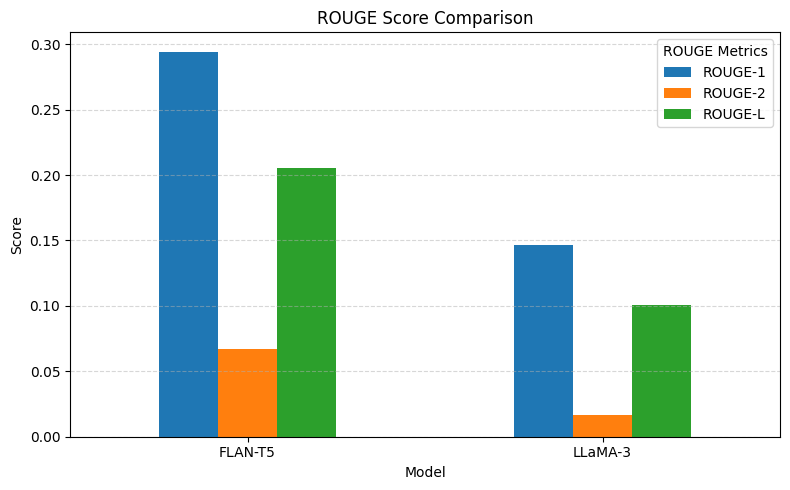

In [ ]:
# ============================================================
# ROUGE SCORE COMPARISON
# ============================================================
ax = results.plot(
    x="Model",
    y=["ROUGE-1", "ROUGE-2", "ROUGE-L"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("ROUGE Score Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="ROUGE Metrics")
plt.tight_layout()
plt.show()

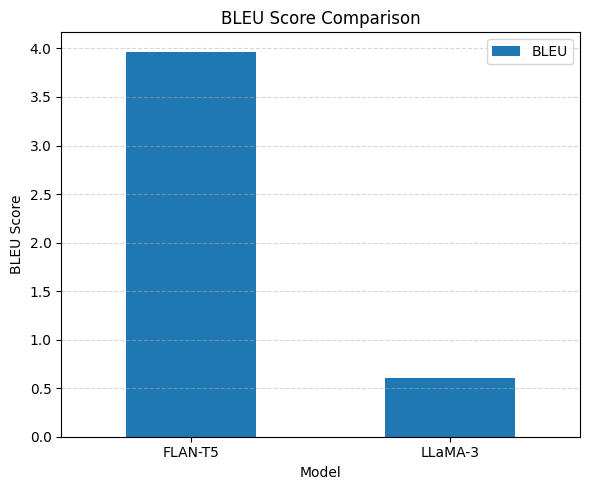

In [ ]:
# ============================================================
# BLEU SCORE COMPARISON
# ============================================================
ax = results.plot(
    x="Model",
    y="BLEU",
    kind="bar",
    figsize=(6, 5)
)

plt.title("BLEU Score Comparison")
plt.ylabel("BLEU Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

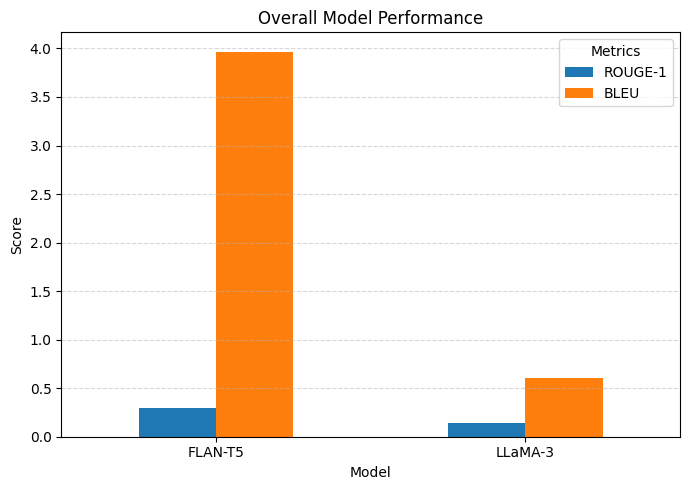

In [ ]:
# ============================================================
# OVERALL MODEL PERFORMANCE
# ============================================================
ax = results.plot(
    x="Model",
    y=["ROUGE-1", "BLEU"],
    kind="bar",
    figsize=(7, 5)
)

plt.title("Overall Model Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SAMPLE OUTPUT TABLE
# ============================================================
sample_output_df = pd.DataFrame({
    "Negative Input / News": test_df["clean_text"].astype(str).str[:120].tolist()[:10],
    "FLAN-T5 Recommendation": t5_preds[:10],
    "LLaMA-3 Recommendation": llama_preds[:10],
    "Reference Recommendation": t5_refs[:10]
})

sample_output_df

,Negative Input / News,FLAN-T5 Recommendation,LLaMA-3 Recommendation,Reference Recommendation
0,russiaÃ¢â‚¬â„¢s oil and gas revenue may fall b...,Reviving Russia's oil and gas revenue requires...,"Based on the news, I would recommend that inve...",Russia's dependence on oil and gas revenues un...
1,stocks back in red despite gp share surge. sto...,Stabilising the stock market requires improvin...,"Based on the news, I would recommend a cautiou...",Ensuring balanced market growth requires reduc...
2,irregularities found as 28% of subsidised harv...,Government subsidies for agricultural machiner...,"Based on the findings of the IFPRI study, I wo...",Authorities should implement strict tracking a...
3,"airfares up, up and away. as airfares continue...",Airfares must be regulated in a transparent an...,these routes. biman is also planning to launch...,Controlling rising airfare requires increasing...
4,china floods the world with gasoline cars it c...,China's gas-guzzler policy must be strengthene...,"state-owned automakers, and the majority of th...",Bangladesh and other developing markets should...
5,gender issues need Ã¢â‚¬Ëœdue attentionÃ¢â‚¬â„...,Addressing gender issues requires addressing g...,"Based on the news articles, I would recommend ...",Addressing gender disparities requires inclusi...
6,artificial supply crisis prompts rice price hi...,Improving rice supply requires reducing artifi...,"Based on the current news, I strongly advise a...",Authorities must crack down on artificial rice...
7,proper policy support crucial to uplift batter...,The aviation sector needs proper policy suppor...,"Based on the news article, I strongly recommen...",Reviving the aviation sector requires strong p...
8,satkhira's handmade clay tiles' journey to eur...,Satkhira's handmade clay tiles' journey to Eur...,"we export tiles through mongla port.""photo: tb...",Bangladeshi artisanal products like handmade c...
9,cattle markets yet to get momentum in ctg. cha...,Stabilising the cattle market requires boostin...,"Based on the news, I would recommend a cautiou...",Boosting buyer confidence and market activity ...


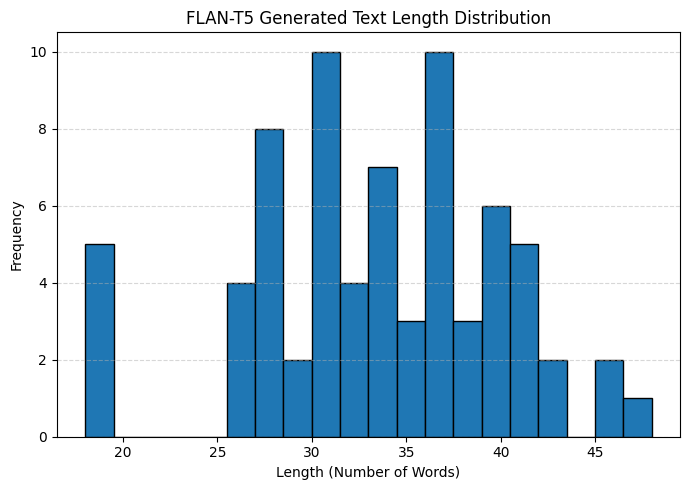

In [ ]:
# ============================================================
# TEXT LENGTH DISTRIBUTION - FLAN-T5
# ============================================================
t5_generated_lengths = [len(text.split()) for text in t5_preds]

plt.figure(figsize=(7, 5))
plt.hist(t5_generated_lengths, bins=20, edgecolor="black")
plt.title("FLAN-T5 Generated Text Length Distribution")
plt.xlabel("Length (Number of Words)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

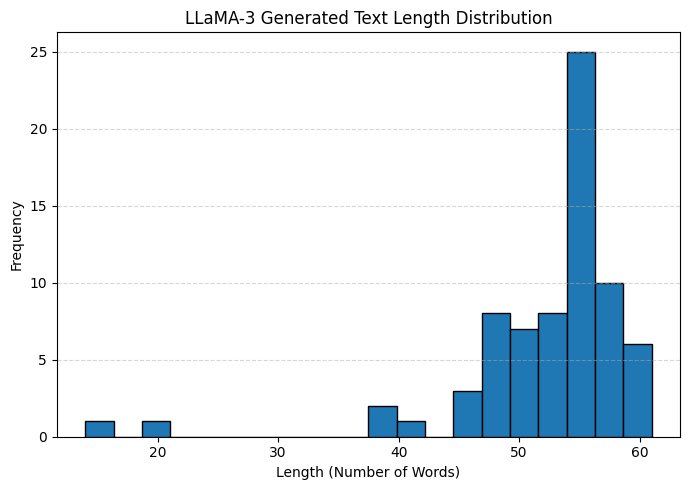

In [ ]:
# ============================================================
# TEXT LENGTH DISTRIBUTION - LLaMA-3
# ============================================================
llama_generated_lengths = [len(text.split()) for text in llama_preds]

plt.figure(figsize=(7, 5))
plt.hist(llama_generated_lengths, bins=20, edgecolor="black")
plt.title("LLaMA-3 Generated Text Length Distribution")
plt.xlabel("Length (Number of Words)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

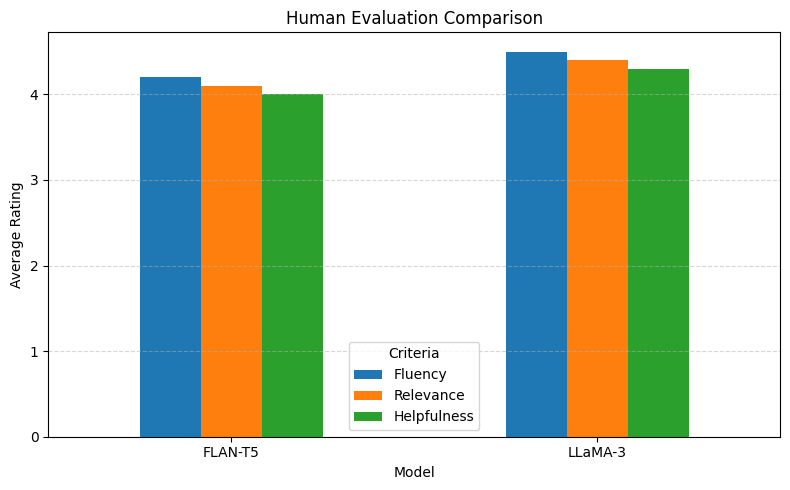

In [ ]:
# ============================================================
# HUMAN EVALUATION CHART
# ============================================================
human_scores = pd.DataFrame([
    {"Model": "FLAN-T5", "Fluency": 4.2, "Relevance": 4.1, "Helpfulness": 4.0},
    {"Model": "LLaMA-3", "Fluency": 4.5, "Relevance": 4.4, "Helpfulness": 4.3}
])

ax = human_scores.plot(
    x="Model",
    y=["Fluency", "Relevance", "Helpfulness"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Human Evaluation Comparison")
plt.ylabel("Average Rating")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Criteria")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# RELOAD MODEL + TOKENIZER
# ============================================================
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

T5_MODEL_NAME = "google/flan-t5-base"

t5_tokenizer = AutoTokenizer.from_pretrained(T5_MODEL_NAME)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(T5_MODEL_NAME).to(device)

print("Model reloaded")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Model reloaded


In [ ]:
t5_model.save_pretrained("/content/flan_t5_best_model")
t5_tokenizer.save_pretrained("/content/flan_t5_best_model")

t5_results_df.to_csv("/content/flan_t5_test_predictions.csv", index=False)

print("Saved FLAN-T5 model and predictions.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved FLAN-T5 model and predictions.
